In [ ]:
import pandas as pd
import numpy as np  
from datetime import datetime, date
import matplotlib.pyplot as plt
import seaborn



In [423]:
lb_df = pd.read_csv("/Users/heerperchani/Desktop/AI4Good/furcast/datasets/animal-shelter-intakes-and-outcomes.csv")
# lb_df[lb_df.duplicated(subset="Animal ID",keep=False)]

,Kennel ID,Animal ID,Animal Name,Animal Type,Primary Color,Secondary Color,Sex,DOB,Intake Date,Intake Condition,...,longitude,intake_is_dead,geopoint,intake_duration,is_current_month,outcome_is_dead,outcome_is_current,outcome_is_other,outcome_is_alive,was_outcome_alive
1,285586,A591341,NaN,CAT,CALICO,NaN,Unknown,2017-05-20,2017-06-04,UNDER AGE/WEIGHT,...,-118.107586,Alive on Intake,"33.816764, -118.1075857",1.0,False,False,False,False,True,1
11,308041,A606500,*BANANNA BLUE,CAT,BLACK,WHITE,Neutered,2012-11-16,2019-08-26,NORMAL,...,-118.196484,Alive on Intake,"33.81766650000001, -118.196484",0.0,False,False,False,False,True,1
22,320793,A648582,*GAMORA,CAT,GRAY TABBY,WHITE,Spayed,2020-07-10,2020-11-25,BEHAVIOR MILD,...,-118.280657,Alive on Intake,"34.0660343, -118.2806572",3.0,False,False,False,False,True,1
27,351780,A708759,*VALLORIA,DOG,BLACK,BROWN,Spayed,2023-04-13,2023-10-13,I/I REPORT,...,-118.152360,Alive on Intake,"33.8762965, -118.1523595",23.0,False,False,False,False,True,1
48,343078,A696087,NINA,DOG,BLACK,WHITE,Female,2022-11-10,2023-04-04,INJURED MODERATE,...,-118.155648,Alive on Intake,"33.873364, -118.1556482",5.0,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55172,384890,A746481,*CHAMPION,DOG,WHITE,BROWN,Neutered,2023-08-02,2025-08-15,NORMAL,...,-118.128498,Alive on Intake,"33.7973401, -118.1284976",36.0,False,False,False,False,True,1
55194,334391,A556069,SNOW,CAT,FLAME PT,NaN,Neutered,2014-06-01,2022-06-04,NORMAL,...,-118.179095,Alive on Intake,"33.8543545, -118.1790948",48.0,False,False,False,False,True,1
55296,354881,A710503,*RIGGS,DOG,WHITE,GRAY,Neutered,2020-11-14,2024-02-10,NORMAL,...,-118.110738,Alive on Intake,"33.8566606, -118.1107378",71.0,False,False,False,False,True,1
55324,336480,A678401,*MELROSE,DOG,YELLOW,NaN,Spayed,2021-06-26,2022-07-15,NORMAL,...,-118.036877,Alive on Intake,"33.8558316, -118.0368767",1.0,False,False,False,False,True,1


In [ ]:
#removing the columns we will not be using 
lb_df_cleaned = lb_df.drop(["Kennel ID","latitude","longitude","Animal Name","Secondary Color","Intake Subtype","Reason for Intake","Crossing","Jurisdiction","Outcome Subtype","outcome_is_dead","was_outcome_alive","geopoint","is_current_month", "intake_duration","outcome_is_current","outcome_is_other","outcome_is_alive","intake_is_dead"], axis=1)


In [376]:
age_days = pd.to_datetime(lb_df_cleaned["Intake Date"]) - pd.to_datetime(lb_df_cleaned["DOB"])
age_days.head()

lb_df_cleaned["age_in_years"] = (age_days /pd.to_timedelta(365.4525, "D")).round(2)

#age added in years 



In [377]:
days_spent = pd.to_datetime(lb_df_cleaned["Outcome Date"]) - pd.to_datetime(lb_df_cleaned["Intake Date"])
lb_df_cleaned["duration_in_days"] = days_spent/pd.to_timedelta(1,"D") #this is float num of days
#numbers of days spent in shelter added



In [402]:
#tried looking for duplicates but no rows were dropped 
lb_df_cleaned.drop_duplicates()
lb_df_cleaned[lb_df_cleaned["age_in_years"].isna()]

#there are 6968 rows with no DOB so no age 


,Animal ID,Animal Type,Primary Color,Sex,DOB,Intake Date,Intake Condition,Intake Type,Outcome Date,Outcome Type,age_in_years,duration_in_days
4,A598491,WILD,GRAY,Unknown,NaN,2017-10-09,INJURED SEVERE,WILDLIFE,2017-10-09,TRANSFER,NaN,0.0
32,A756063,CAT,GRAY TABBY,Neutered,NaN,2026-02-07,INJURED MILD,STRAY,2026-02-23,COMMUNITY CAT,NaN,16.0
41,A721269,CAT,ORANGE,Male,NaN,2024-05-21,ILL MILD,STRAY,2024-05-23,EUTHANASIA,NaN,2.0
61,A644651,BIRD,BROWN,Unknown,NaN,2020-07-01,INJURED MILD,WILDLIFE,2020-07-01,EUTHANASIA,NaN,0.0
63,A644112,OTHER,GRAY,Female,NaN,2020-06-20,INJURED SEVERE,WILDLIFE,2020-06-20,RETURN TO WILD HABITAT,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
55282,A611520,GUINEA PIG,TRICOLOR,Unknown,NaN,2018-07-23,NORMAL,CONFISCATE,2018-08-04,ADOPTION,NaN,12.0
55293,A648274,CAT,BLACK,Male,NaN,2020-09-04,INJURED MODERATE,STRAY,2020-09-11,TRANSFER,NaN,7.0
55303,A740863,CAT,BLACK,Male,NaN,2025-05-17,UNDER AGE/WEIGHT,STRAY,2025-05-24,DIED,NaN,7.0
55309,A667743,BIRD,BROWN,Unknown,NaN,2021-12-07,INJURED MODERATE,WILDLIFE,2021-12-07,TRANSFER,NaN,0.0


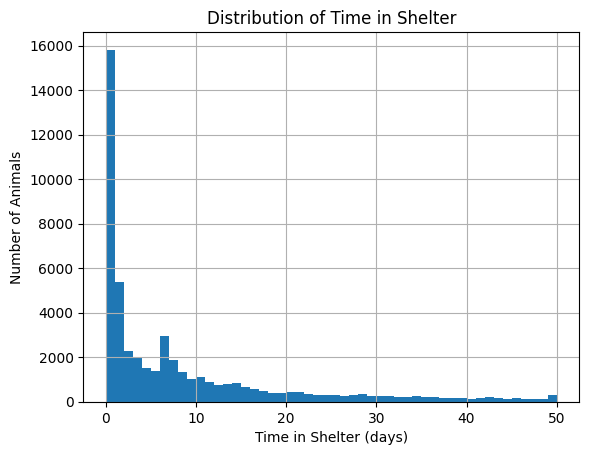

In [431]:
lb_df_cleaned[lb_df_cleaned["duration_in_days"] <= 50]["duration_in_days"].hist(bins=50)
plt.xlabel("Time in Shelter (days)")
plt.ylabel("Number of Animals")
plt.title("Distribution of Time in Shelter")
plt.show()

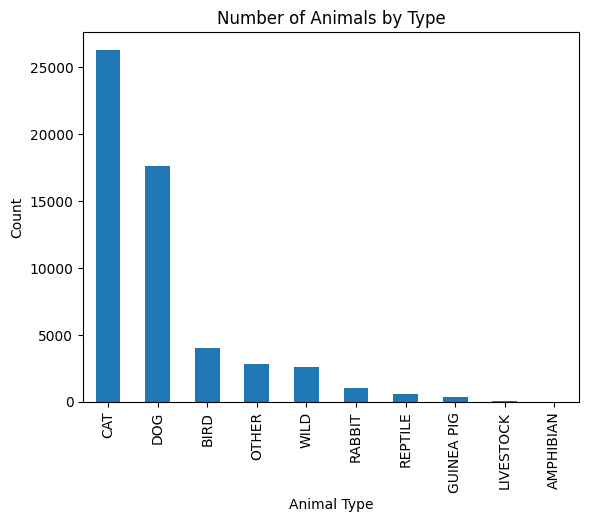

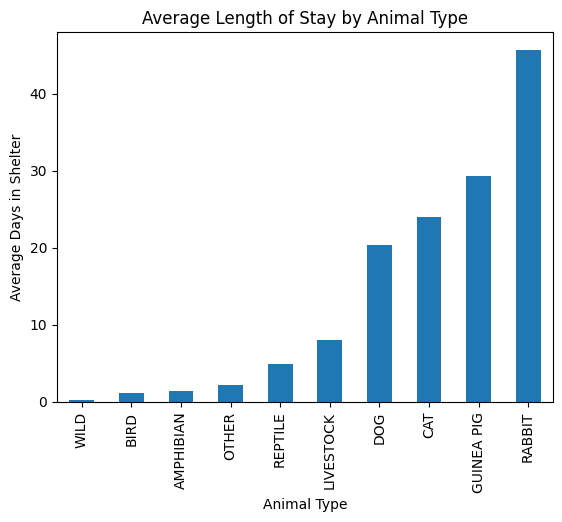

,count,mean,median
Animal Type,,,
RABBIT,1035,45.718841,19.0
GUINEA PIG,320,29.275000,14.0
CAT,26030,24.021744,7.0
DOG,17534,20.375442,6.0
LIVESTOCK,21,8.000000,3.0
REPTILE,600,4.953333,3.0
OTHER,2818,2.161462,0.0
AMPHIBIAN,3,1.333333,2.0
BIRD,3995,1.153942,0.0


In [435]:
#Count how many animals are in each animal type category
lb_df_cleaned["Animal Type"].value_counts().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.title("Number of Animals by Type")
plt.show()

#Calculate average length of stay for each animal type
lb_df_cleaned.groupby("Animal Type")["duration_in_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Animal Type")
plt.show()

lb_df_cleaned.groupby("Animal Type")["duration_in_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

#Intepretation: 
# Dogs is the largest number of animals in the data. 
# Cats have the highest average length of stay

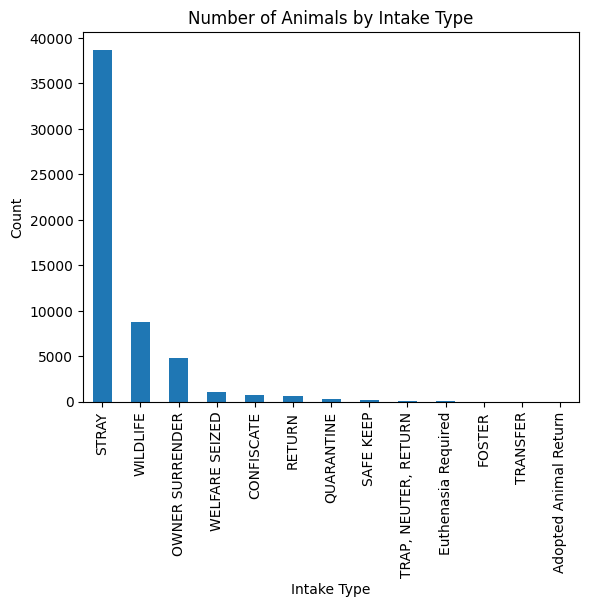

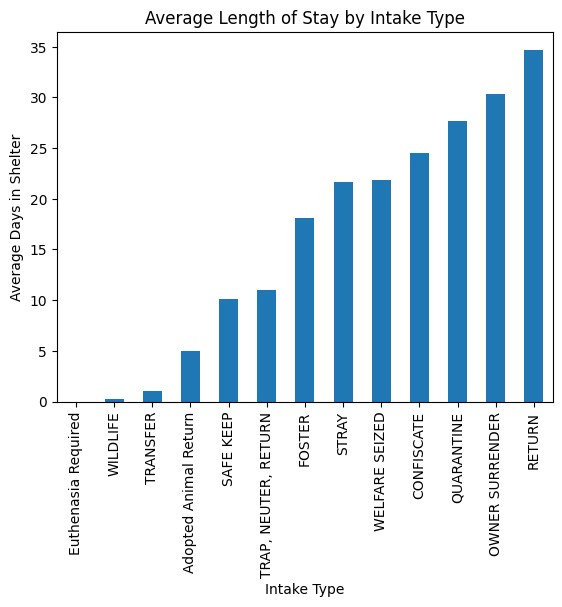

In [436]:
# Distribution of intake types
# Shows how many animals came into the shelter for each intake type
lb_df_cleaned["Intake Type"].value_counts().plot(kind="bar")
plt.xlabel("Intake Type")
plt.ylabel("Count")
plt.title("Number of Animals by Intake Type")
plt.show()

# Average length of stay by intake type
# Shows which intake types have longer/shorter stays
lb_df_cleaned.groupby("Intake Type")["duration_in_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Intake Type")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Intake Type")
plt.show()

# Interpretation:
# Stray animals make up the largest intake group. 
# However, owner surrendered animals have the highest average length of stay
# intake type may be useful for predicting how long an animal stays in shelter.

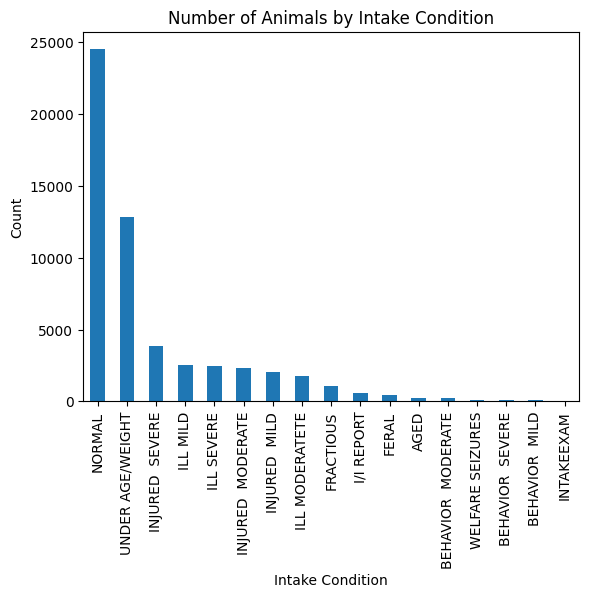

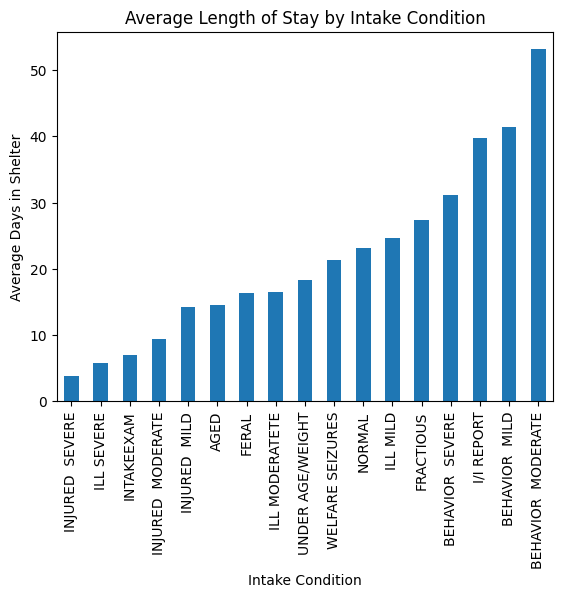

,count,mean,median
Intake Condition,,,
BEHAVIOR MODERATE,241,53.124481,19.0
BEHAVIOR MILD,110,41.454545,13.5
I/I REPORT,564,39.726950,13.0
BEHAVIOR SEVERE,127,31.165354,12.0
FRACTIOUS,1084,27.317343,14.0
ILL MILD,2532,24.691153,8.0
NORMAL,24369,23.106447,7.0
WELFARE SEIZURES,132,21.363636,7.0
UNDER AGE/WEIGHT,12676,18.289050,2.0


In [437]:
# Distribution of intake conditions
# Shows how many animals came into the shelter under each condition
lb_df_cleaned["Intake Condition"].value_counts().plot(kind="bar")
plt.xlabel("Intake Condition")
plt.ylabel("Count")
plt.title("Number of Animals by Intake Condition")
plt.show()

# Average length of stay by intake condition
# Shows which intake conditions have longer/shorter stays
lb_df_cleaned.groupby("Intake Condition")["duration_in_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Intake Condition")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Intake Condition")
plt.show()

lb_df_cleaned.groupby("Intake Condition")["duration_in_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

# Interpretation:
# Most animals enter shelter in normal conditions. 
# Animals with less common intake conditions have higher stays
# Could be useful for prediciting length of stay

In [442]:

lb_df_cleaned["Intake Type"].unique()

<StringArray>
[                'STRAY',       'OWNER SURRENDER',              'WILDLIFE',
        'WELFARE SEIZED',            'CONFISCATE',                'RETURN',
             'SAFE KEEP',            'QUARANTINE',  'TRAP, NEUTER, RETURN',
   'Euthenasia Required', 'Adopted Animal Return',              'TRANSFER',
                'FOSTER']
Length: 13, dtype: str